# Random Forest – Customer Churn Prediction

A telecom provider wants to predict whether a customer will churn (leave the company) based on customer attributes and service usage patterns.



## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the Dataset

In Google Colab a file picker opens so the CSV can be uploaded. If the notebook is run locally, the CSV is read from the current folder instead.

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

`head()` shows the first five rows, so we can see what the columns look like and what kind of values they hold.

In [ ]:
df.shape

(7043, 21)

`shape` gives the number of rows (customers) and columns (variables).

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

`columns` lists all variable names. This is important later because we must use the exact column names when selecting features.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


`info()` shows the data type and non-null count of every column. Here we should check whether numerical columns are stored as numbers. `TotalCharges` appears as `object` (text) even though it should be numeric, so it needs to be fixed during cleaning.

## 3. Basic Data Understanding

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Checking for missing values. There are no NaN values yet, but `TotalCharges` is stored as text, so blank entries may be hiding inside it.

In [ ]:
df.duplicated().sum()

np.int64(0)

Checking for duplicate rows

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


## 4. Data Cleaning



In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [ ]:
df = df.dropna()
print( df.shape)
print("Remaining missing values:", df["TotalCharges"].isnull().sum())

(7032, 21)
Remaining missing values: 0


Now the target `Churn` is converted to numbers: No = 0, Yes = 1.

In [ ]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


## 5. Statistical Analysis

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


Main points from the numerical summary:

- **tenure:** mean is about 32.4 months, median is 29, standard deviation is about 24.5. The values range from 1 to 72 months. Since the mean is slightly higher than the median, there is a small pull towards higher values, and the wide standard deviation shows that customers are spread across all tenure lengths.
- **MonthlyCharges:** mean is about 64.8 and median is about 70.35. The median is higher than the mean, so a group of customers with low charges pulls the mean down. The standard deviation is about 30.1 and charges range from 18.25 to 118.75.
- **TotalCharges** has a very large range and spread because it grows with tenure (it is roughly tenure multiplied by monthly charges).
- **SeniorCitizen** is a 0/1 column, so its mean (about 0.16) is simply the fraction of senior citizens.

In [ ]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
0    5163
1    1869
Name: count, dtype: int64

Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [ ]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


About 73.4% of customers did not churn and 26.6% did. Most customers are on month-to-month contracts (3875), followed by two-year (1685) and one-year (1472) contracts.

## 6. Exploratory Data Analysis

### 6.1 Churn Distribution

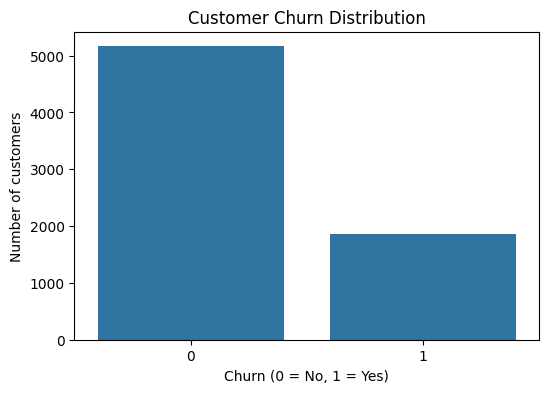

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of customers")
plt.show()

**Observation:** The target is imbalanced. There are roughly three times as many customers who stayed (5163) as customers who churned (1869).  a model that always predicts "No churn" would already reach about 73% accuracy, so accuracy alone can be misleading and we also need precision and recall for the churn class.

### 6.2 Monthly Charges Distribution

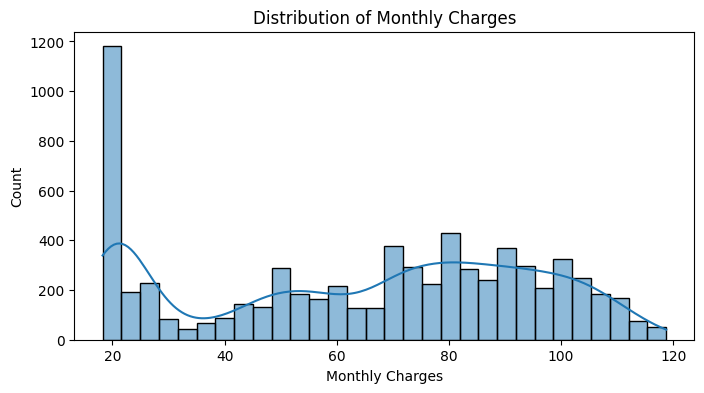

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["MonthlyCharges"], kde=True, bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.show()

**Observation:** The distribution is not a single bell shape. There is a very tall bar at the low end (about 18 to 28), where about 1600 customers are concentrated, and then a broad group of customers spread between roughly 60 and 110.

### 6.3 Tenure Distribution

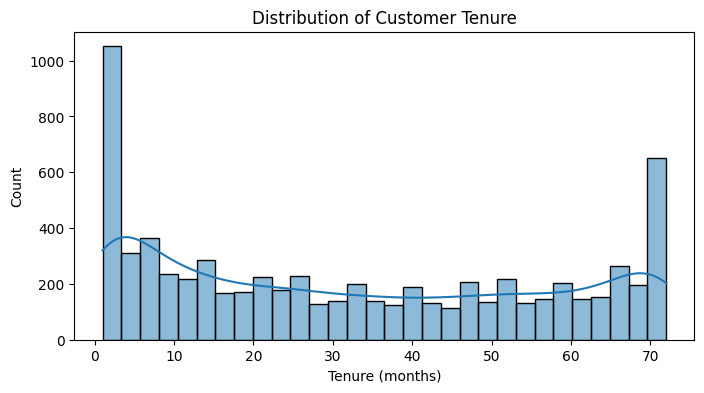

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["tenure"], kde=True, bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.show()

**Observation:** Tenure has high counts at both ends. Many customers are very new (613 customers have only 1 month of tenure) and many are long-term (362 customers have the maximum of 72 months), with fewer customers in between.

### 6.4 Monthly Charges vs Churn

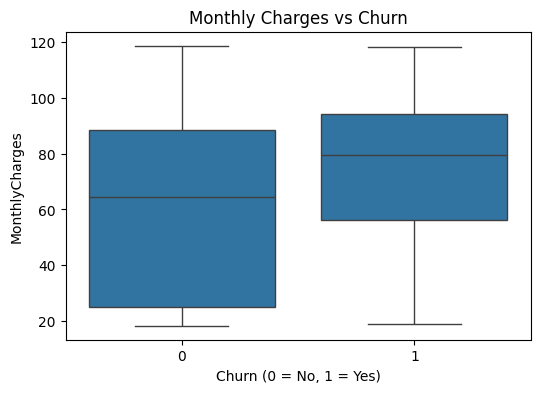

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.show()

**Observation:** Customers who churned have higher monthly charges. The median for churned customers is about 79.65 compared with about 64.45 for customers who stayed, and the whole box for churned customers sits higher.

### 6.5 Tenure vs Churn

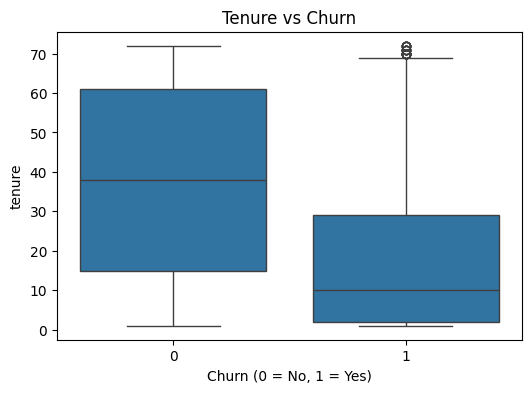

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.show()

**Observation:** Customers who churned have much shorter tenure. The median tenure is about 10 months for churned customers and about 38 months for customers who stayed. So churn is concentrated among newer customers.

### 6.6 Contract vs Churn

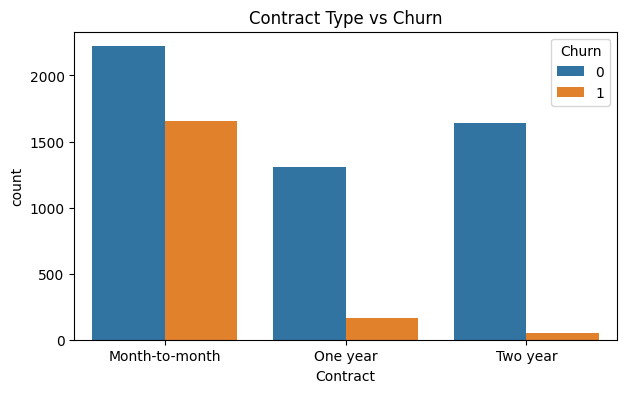

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.show()

**Observation:** Month-to-month contracts have by far the most churned customers (1655 out of 3875, about 42.7%). For one-year contracts the churn rate is about 11.3% (166 out of 1472) and for two-year contracts it is only about 2.8% (48 out of 1685).

### 6.7 Correlation Heatmap

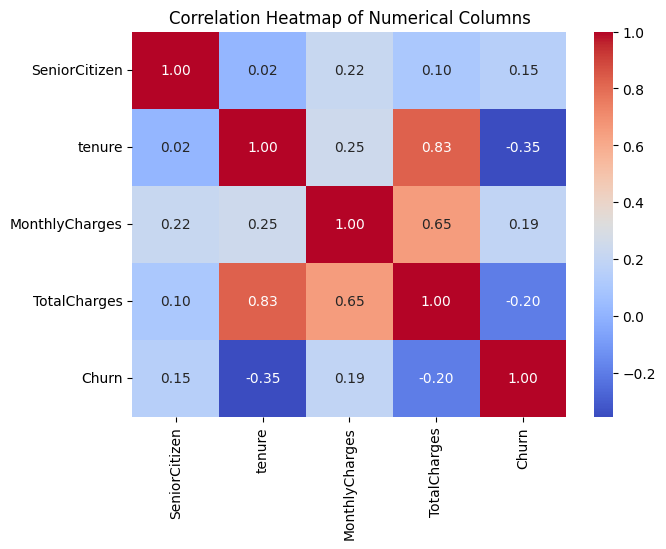

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

**Observation:**
- `tenure` has the strongest correlation with `Churn` (about -0.35): longer tenure goes with less churn.
- `MonthlyCharges` has a positive correlation with `Churn` (about 0.19), which matches the boxplot.
- `TotalCharges` has a negative correlation with `Churn` (about -0.20). It is also strongly correlated with `tenure` (about 0.83), because total charges accumulate over time.
- Correlation only measures linear relationships, and `Churn` is a 0/1 column, so these values are only a rough guide.

## 7. Feature Selection

The assignment mentions four features: `MonthlyCharges`, `tenure`, `SupportCalls` and `Contract`.  dataset does not contain a `SupportCalls` column. It has `TechSupport`, so it is not used as a replacement.

In [ ]:
print("SupportCalls in dataset:", "SupportCalls" in df.columns)

SupportCalls in dataset: False


In [ ]:
features = ["MonthlyCharges", "tenure", "Contract"]


if "SupportCalls" in df.columns:
    features.append("SupportCalls")

target = "Churn"

X = df[features]
y = df[target]

print("Features used:", features)
X.head()

Features used: ['MonthlyCharges', 'tenure', 'Contract']


,MonthlyCharges,tenure,Contract
0,29.85,1,Month-to-month
1,56.95,34,One year
2,53.85,2,Month-to-month
3,42.30,45,One year
4,70.70,2,Month-to-month


Since `SupportCalls` is not available in this dataset, the model uses `MonthlyCharges`, `tenure` and `Contract`.

## 8. Feature Encoding

A Random Forest works with numbers, not text. `Contract` contains text categories (Month-to-month, One year, Two year), so it is converted into numeric columns using one-hot encoding.

In [ ]:
X = pd.get_dummies(X, columns=["Contract"], drop_first=True)
X.head()

,MonthlyCharges,tenure,Contract_One year,Contract_Two year
0,29.85,1,False,False
1,56.95,34,True,False
2,53.85,2,False,False
3,42.30,45,True,False
4,70.70,2,False,False


## 9. Train-Test Split



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print( X_test.shape)
print( round(y_train.mean(), 3))
print( round(y_test.mean(), 3))

(5625, 4)
(1407, 4)
0.266
0.266


## 10. Random Forest Model



In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 11. Predictions



In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("First 10 predicted classes:", y_pred[:10])
print()
print("First 5 probabilities [No Churn, Churn]:")
print(y_prob[:5].round(3))

First 10 predicted classes: [0 0 0 0 0 0 0 0 1 0]

First 5 probabilities [No Churn, Churn]:
[[1.   0.  ]
 [0.78 0.22]
 [1.   0.  ]
 [0.99 0.01]
 [0.93 0.07]]


## 12. Model Evaluation

### Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.7498


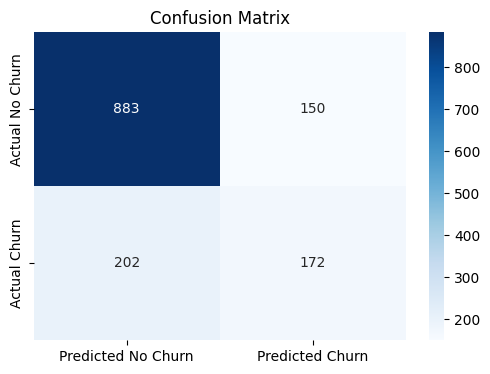

True Negative  (stayed, predicted stay): 883
False Positive (stayed, predicted churn): 150
False Negative (churned, predicted stay): 202
True Positive  (churned, predicted churn): 172


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted No Churn", "Predicted Churn"],
            yticklabels=["Actual No Churn", "Actual Churn"])
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True Negative  (stayed, predicted stay):", tn)
print("False Positive (stayed, predicted churn):", fp)
print("False Negative (churned, predicted stay):", fn)
print("True Positive  (churned, predicted churn):", tp)

- **True Negative (883):**
- **False Positive (150):**
- **False Negative (202):**
- **True Positive (172):**

The model finds fewer churners (172) than it misses (202).

### Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1033
           1       0.53      0.46      0.49       374

    accuracy                           0.75      1407
   macro avg       0.67      0.66      0.66      1407
weighted avg       0.74      0.75      0.74      1407



## 13. Feature Importance

`feature_importances_` shows how much each feature contributed to reducing impurity (Gini impurity) across all the trees. A higher value means the feature was more useful for splitting the data.

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
0,MonthlyCharges,0.618690
1,tenure,0.290411
3,Contract_Two year,0.053478
2,Contract_One year,0.037420


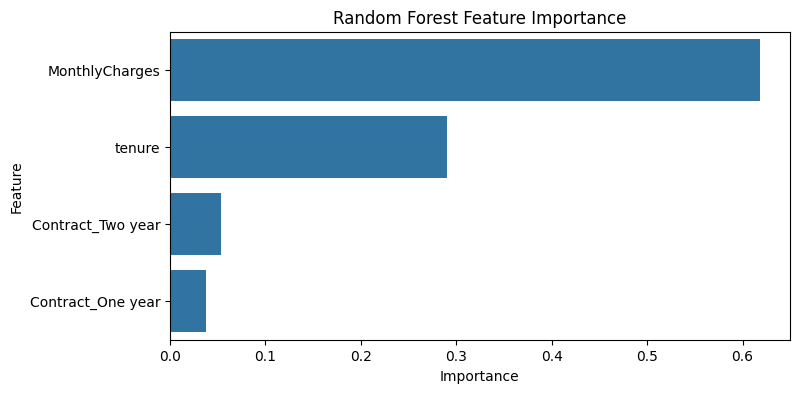

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

## 14. Predict the Given Customer



- MonthlyCharges = 70
- Tenure = 8
- Contract = Month-to-month

The dataset does not have `SupportCalls`, so that value (4 in the assignment) cannot be used. The new customer must have exactly the same columns as the training data. Month-to-month is the category that was dropped by `drop_first=True`, so both contract columns are 0.

In [ ]:
new_customer = pd.DataFrame({
    "MonthlyCharges": [70],
    "tenure": [8],
    "Contract_One year": [0],
    "Contract_Two year": [0]
})

# Same column order as the training data
new_customer = new_customer[X_train.columns]

pred_class = model.predict(new_customer)[0]
pred_prob = model.predict_proba(new_customer)[0]

print("Customer details")
print("  MonthlyCharges: 70")
print("  Tenure: 8 months")
print("  Contract: Month-to-month")
print("  SupportCalls: not available in this dataset")
print()
print("Predicted class:", pred_class, "->", "Churn" if pred_class == 1 else "No Churn")
print("No Churn probability:", round(pred_prob[0], 3))
print("Churn probability:", round(pred_prob[1], 3))

Customer details
  MonthlyCharges: 70
  Tenure: 8 months
  Contract: Month-to-month
  SupportCalls: not available in this dataset

Predicted class: 0 -> No Churn
No Churn probability: 0.755
Churn probability: 0.245


## 15. Final Conclusion

1. **Purpose:** A Random Forest classifier with 100 trees was used to predict whether a telecom customer will churn, using `MonthlyCharges`, `tenure` and `Contract` from the Telco Customer Churn dataset.
2. **Results:** The model reached an accuracy of about 75% on the test set. This is only a little higher than the roughly 73% obtained by always predicting "No churn", because the data is imbalanced. For the churn class, precision is about 0.53, recall about 0.46 and F1-score about 0.49, so the model misses more than half of the customers who actually churn. The performance is moderate, not strong.
3. **Important features:** According to the model, `MonthlyCharges` (about 0.62) and `tenure` (about 0.29) are the most important features. In the EDA, churned customers had higher monthly charges, shorter tenure, and were mostly on month-to-month contracts (about 42.7% churn versus about 2.8% for two-year contracts).
4. **Given customer:** For MonthlyCharges = 70, Tenure = 8 and a Month-to-month contract, the model predicts **No Churn**, with a probability of about 0.75 for No Churn and about 0.25 for Churn. Since this customer has features that the EDA linked with higher churn (short tenure, month-to-month contract), it is worth noting that the churn probability is still below the 0.5 threshold.
5. **Limitation:** The standard Kaggle dataset does not contain `SupportCalls`, so this feature could not be used and the prediction for the given customer does not include `SupportCalls = 4`. The model might perform differently if that feature were available.